In [1]:
import rmgpy.chemkin
import os

import cantera as ct
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import rmgpy.solver
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import rmgpy.tools.plot

In [2]:
chemkin = 'rmg_run/chem_annotated-gas.inp'
chemkin_surf = 'rmg_run/chem_annotated-surface.inp'
spec_dict = 'rmg_run/species_dictionary.txt'
mech_yaml = 'rmg_run/chem_annotated.yaml'


gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

# chemkin = '/home/moon/uncertainty_estimator/cpox_pt/cpox_rh_emily/chem_annotated-gas.inp'
# chemkin_surf = '/home/moon/uncertainty_estimator/cpox_pt/cpox_rh_emily/chem_annotated-surface.inp'
# spec_dict = '/home/moon/uncertainty_estimator/cpox_pt/cpox_rh_emily/species_dictionary.txt'
# mech_yaml = '/home/moon/uncertainty_estimator/cpox_pt/cpox_rh_emily/chem_annotated-gas.yaml'

# gas = ct.Solution(mech_yaml)
# surf = ct.Interface(mech_yaml, "surface1", [gas])



species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surf)

In [3]:
surface_reaction_list = [x for x in reaction_list if x.is_surface_reaction()]
assert len(surface_reaction_list) == surf.n_reactions

# Make sure the reactions are in the same order
def same_reaction(rmg_rxn, ct_rxn):
    # TODO make this more rigorous
    rmg_r = set([str(x.to_chemkin()) for x in rmg_rxn.reactants])
    rmg_p = set([str(x.to_chemkin()) for x in rmg_rxn.products])

    ct_r = set(ct_rxn.reactants.keys())
    ct_p = set(ct_rxn.products.keys())
    return rmg_r == ct_r and rmg_p == ct_p
for i in range(len(surface_reaction_list)):
    # if i in [40]:  # for some reason this is names differently in Emily's mech
    #     continue
    assert same_reaction(surface_reaction_list[i], surf.reactions()[i]), i

# For each surface reaction, check the units

## Break this up by reaction order

In [4]:
rmg_units_to_order = {
    '': 'Sticking',
    's^-1': 'Zero',
    'cm^2/(mol*s)': 'First',
    'cm^4/(mol^2*s)': 'Second',    
}

### Unitless/sticking

In [5]:
print('Index\tRMG A\t\tCantera A')
print('--------------------------------------------')
for i in range(len(surface_reaction_list)):
    order = rmg_units_to_order[surface_reaction_list[i].kinetics.A.units]
    if order == 'Sticking':
        print(f'{i}\t{surface_reaction_list[i].kinetics.A}\t\t{surf.reactions()[i].rate.pre_exponential_factor}')
        assert np.isclose(surface_reaction_list[i].kinetics.A.value_si, surf.reactions()[i].rate.pre_exponential_factor)

Index	RMG A		Cantera A
--------------------------------------------
0	0.07		0.07
1	0.84		0.84
2	0.046		0.046
3	0.005		0.005
10	0.04		0.04
14	1		1.0
15	0.75		0.75
18	0.85		0.85
19	0.85		0.85
20	0.008		0.008
21	0.85		0.85
22	0.85		0.85
23	0.02		0.02
24	0.2		0.2
25	0.015		0.015
26	0.2		0.2
27	0.01		0.01
28	0.015		0.015
29	0.015		0.015
30	0.01		0.01
79	0.015		0.015
80	0.0075		0.0075
81	0.0075		0.0075
123	0.1		0.1
124	0.83		0.83
125	7e-06		7e-06
126	0.01		0.01
144	0.83		0.83


### Zero order $A \rightleftharpoons B \ (s^{-1})$ 

In [6]:
print('Index\tRMG A\t\tCantera A')
print('---------------------------------------------------------')
for i in range(len(surface_reaction_list)):
    rmg_units = surface_reaction_list[i].kinetics.A.units
    order = rmg_units_to_order[rmg_units]
    if order == 'Zero':
        print(f'{i}\t{surface_reaction_list[i].kinetics.A.value_si:.2e} {rmg_units}\t\t{surf.reactions()[i].rate.pre_exponential_factor:.2e}\t{surf.reactions()[i].rate_coeff_units}')
        assert np.isclose(surface_reaction_list[i].kinetics.A.value_si, surf.reactions()[i].rate.pre_exponential_factor)

Index	RMG A		Cantera A
---------------------------------------------------------
82	4.22e+12 s^-1		4.22e+12	1 / s
83	1.30e+12 s^-1		1.30e+12	1 / s
98	7.93e+12 s^-1		7.93e+12	1 / s
127	4.22e+12 s^-1		4.22e+12	1 / s
155	4.22e+12 s^-1		4.22e+12	1 / s


### First Order $A+B \rightleftharpoons C+D$

In [7]:
print('Index\tRMG A-factor\t\t\tCantera A-factor')
print('--------------------------------------------------------')
rmg_SI_units = 'm^2/(mol*s)'
for i in range(len(surface_reaction_list)):
    A = surface_reaction_list[i].kinetics.A
    rmg_units = A.units
    order = rmg_units_to_order[rmg_units]
    if order == 'First':
        assert A.get_conversion_factor_to_si() == 0.0001
        print(f'{i}\t{A.value_si:.2e} {rmg_SI_units}\t\t{surf.reactions()[i].rate.pre_exponential_factor:.2e}\t{surf.reactions()[i].rate_coeff_units}')
        assert np.isclose(A.value_si, surf.reactions()[i].rate.pre_exponential_factor / 1000.0)  # convert Cantera kmol to mol

Index	RMG A-factor			Cantera A-factor
--------------------------------------------------------
4	3.70e+17 m^2/(mol*s)		3.70e+20	m^2 / kmol / s
5	3.09e+18 m^2/(mol*s)		3.09e+21	m^2 / kmol / s
6	3.30e+17 m^2/(mol*s)		3.30e+20	m^2 / kmol / s
7	7.31e+18 m^2/(mol*s)		7.31e+21	m^2 / kmol / s
8	3.70e+15 m^2/(mol*s)		3.70e+18	m^2 / kmol / s
9	3.09e+18 m^2/(mol*s)		3.09e+21	m^2 / kmol / s
12	1.00e+15 m^2/(mol*s)		1.00e+18	m^2 / kmol / s
13	7.39e+15 m^2/(mol*s)		7.39e+18	m^2 / kmol / s
16	1.15e+15 m^2/(mol*s)		1.15e+18	m^2 / kmol / s
17	1.00e+16 m^2/(mol*s)		1.00e+19	m^2 / kmol / s
31	3.14e+17 m^2/(mol*s)		3.14e+20	m^2 / kmol / s
32	4.18e+17 m^2/(mol*s)		4.18e+20	m^2 / kmol / s
33	4.40e+18 m^2/(mol*s)		4.40e+21	m^2 / kmol / s
34	1.39e+17 m^2/(mol*s)		1.39e+20	m^2 / kmol / s
35	2.43e+17 m^2/(mol*s)		2.43e+20	m^2 / kmol / s
36	4.78e+20 m^2/(mol*s)		4.78e+23	m^2 / kmol / s
37	3.30e+17 m^2/(mol*s)		3.30e+20	m^2 / kmol / s
38	4.18e+17 m^2/(mol*s)		4.18e+20	m^2 / kmol / s
39	4.18e+17 m^2/(mol*s)		4.18

### Second Order $A+B+C\rightleftharpoons D+E$

In [8]:
print('Index\tRMG A-factor\t\t\tCantera A-factor')
print('--------------------------------------------------------')
rmg_SI_units = 'm^4/(mol^2*s)'
for i in range(len(surface_reaction_list)):
    A = surface_reaction_list[i].kinetics.A
    rmg_units = A.units
    order = rmg_units_to_order[rmg_units]
    if order == 'Second':
        assert A.get_conversion_factor_to_si() == 0.00000001


        line = f'{i}\t{A.value_si:.2e} {rmg_SI_units}\t\t{surf.reactions()[i].rate.pre_exponential_factor:.2e}\t{surf.reactions()[i].rate_coeff_units}'

        if not np.isclose(A.value_si, surf.reactions()[i].rate.pre_exponential_factor / 1e6):  # convert Cantera kmol^2 to mol^2
            line += '\t<---------------- this is different'
        print(line)

Index	RMG A-factor			Cantera A-factor
--------------------------------------------------------
11	5.00e+10 m^4/(mol^2*s)		5.00e+14	m^5 / kmol^2 / s	<---------------- this is different
96	9.28e+20 m^4/(mol^2*s)		9.28e+26	m^4 / kmol^2 / s
153	1.86e+21 m^4/(mol^2*s)		1.86e+27	m^4 / kmol^2 / s


11

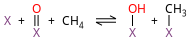

96

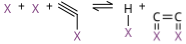

153

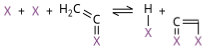

In [9]:
for i in range(len(surface_reaction_list)):
    A = surface_reaction_list[i].kinetics.A
    rmg_units = A.units
    order = rmg_units_to_order[rmg_units]
    if order == 'Second':
        display(i, surface_reaction_list[i])
        print()